# 案例 03 · 延误传播网络：延误从哪来，沿机尾链怎么扩散？

**这个案例回答什么？**
- 延误真的会"传染"吗？——用条件概率（lift）量化"上一班晚到 → 下一班也晚"的放大效应；
- 延误在哪些机场的过站中传播得最狠？——传播枢纽排名；
- 从全网络视角看，谁在向外"输出"延误、谁在吸收？——机场流量强度（sent/received）。

**方法**：同一架飞机的连续执飞构成**机尾号轮转链**（上一航段的到达 → 过站 → 下一航段出发）。
延误沿这条链传播。三个指标全部定义在这张图上（见 [docs/methodology.md](../docs/methodology.md) 第 8 节）。

**诚实话（先说清楚）**
- 主分析使用**合成机队轮转数据**（`synthesize_rotations`：150 架飞机 × 21 天，`SIM-` 前缀注册号）。
  生成器在模型里**显式注入了传播机制**（上一班到达延误 − 时刻恢复量 + 新扰动），因此它是"已知答案的考卷"——
  用来验证方法学本身能否把传播信号从噪声里捞出来，**不代表真实流量**；
- 案例末尾尝试用 **OpenSky 公开 REST 数据**重跑同一套流程做对照（带缓存与重试）；网络不可用时自动回退，不影响主线；
- 链模型只看机尾轮转，不含机组排班、维修、时刻协调等真实因素；所有结论仅供学习。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from routelab.network import (
    airport_centrality,
    build_tail_chain,
    delay_inheritance,
    propagation_hubs,
    synthesize_rotations,
)

flights = synthesize_rotations(n_aircraft=150, n_days=21, seed=42)
print(f"航班数 {len(flights):,} | 机尾 {flights['registration'].nunique()} | "
      f"机场 {flights['destination'].nunique()} | "
      f"平均到达延误 {flights['arrival_delay_min'].mean():.1f} min")
flights.head(3)

航班数 12,619 | 机尾 150 | 机场 8 | 平均到达延误 15.7 min


,registration,origin,destination,sched_dep,sched_arr,actual_arr,arrival_delay_min
0,SIM-0000,ZSPD,ZWWW,2026-07-01 06:28:00.000000000,2026-07-01 11:15:47.670640110,2026-07-01 11:22:32.805998850,6.8
1,SIM-0000,ZWWW,ZSPD,2026-07-01 12:36:47.670640110,2026-07-01 17:24:35.341280220,2026-07-01 17:35:06.499184100,10.5
2,SIM-0000,ZSPD,ZWSH,2026-07-01 19:00:35.341280220,2026-07-02 00:57:25.707441354,2026-07-02 01:05:42.290712305,8.3


## 1. 机尾号轮转链

`build_tail_chain` 把航班表变成图：边 = 同一机尾的连续两班，且计划过站时间
（下一班出发 − 上一班计划到达）不超过 180 分钟。**过夜的休息会重置链**——
这是刻意的设计：航司靠过夜把前一天的延误"洗掉"，我们不把隔天的延误算作传播。

In [2]:
chain = build_tail_chain(flights, max_turnaround_min=180)
n_edges = sum(len(v) for v in chain.values())
per_tail = pd.Series({k: len(v) for k, v in chain.items()})
print(f"有后续班次的航段: {len(chain):,} | 单机最多连续过站: {per_tail.max()}")
# 链边数 n_edges 用于后续小节交叉核对


有后续班次的航段: 9,469 | 单机最多连续过站: 1


## 2. 延误会传染吗：条件概率与 lift

`delay_inheritance` 计算三件事：基线 `P(下一班延误)`、条件概率
`P(下一班延误 | 上一班延误)`，以及两者的比值 **lift**。lift = 1 表示延误独立发生；
lift 明显大于 1 表示延误沿轮转链传播——合成数据在生成时就注入了这个机制，
所以这里的 lift 就是对方法学的"验收"。

In [3]:
rows = []
for t in (15, 30, 60):
    s = delay_inheritance(flights, chain, threshold_min=t)
    rows.append({
        "阈值 min": t,
        "过站对": s["n_pairs"],
        "上一班延误": s["n_prev_delayed"],
        "两班都延误": s["n_propagated"],
        "P(下一班延误)": round(s["p_next_delayed"], 3),
        "P(下一班延误|上一班延误)": round(s["p_next_given_prev"], 3),
        "lift": round(s["lift"], 2),
    })
inheritance_table = pd.DataFrame(rows)
inheritance_table

,阈值 min,过站对,上一班延误,两班都延误,P(下一班延误),P(下一班延误|上一班延误),lift
0,15,9469,1566,1102,0.274,0.704,2.57
1,30,9469,1033,763,0.186,0.739,3.97
2,60,9469,541,409,0.102,0.756,7.43


**读数**：三个阈值下 lift 都显著大于 1，且阈值越高 lift 越大——
越严重的延误越难被恢复时间吸收，传播越"结实"。这与运行常识一致：
15 分钟的延误常常被松的时刻表吃掉，90 分钟的延误几乎必然压到下一班。

## 3. 传播枢纽：延误在哪些机场过站时扩散？

`propagation_hubs` 按过站机场聚合：**传播比例** = 延误越过该机场过站的次数占比，
**继承延误分钟** = 这些传播对里下一班的延误总量。样本太少的机场被过滤（默认 ≥ 30 个过站）。

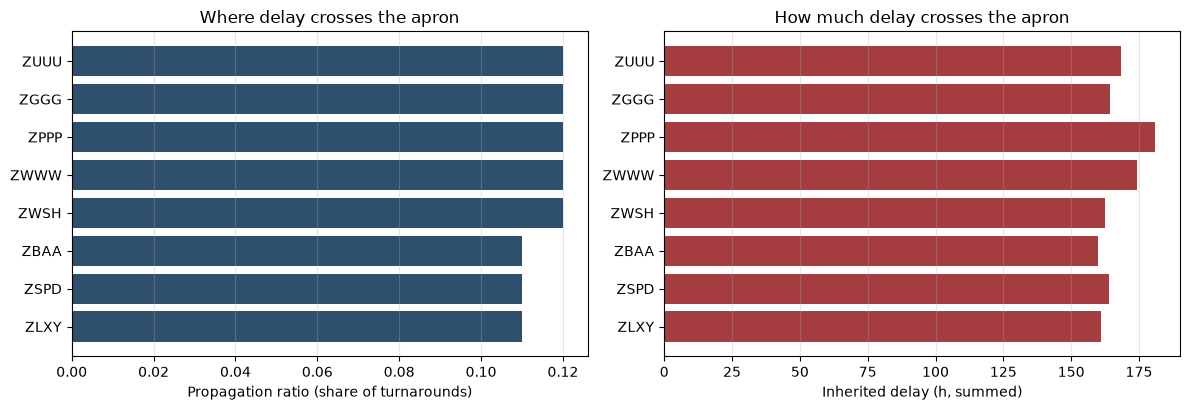

,n_turnarounds,n_propagated,inherited_delay_min,propagation_ratio
hub,,,,
ZUUU,1206,150,10100.42,0.12
ZGGG,1216,149,9851.15,0.12
ZPPP,1215,144,10863.40,0.12
ZWWW,1183,140,10457.00,0.12
ZWSH,1151,135,9756.70,0.12
ZBAA,1138,126,9594.09,0.11
ZSPD,1199,132,9832.87,0.11
ZLXY,1161,126,9667.50,0.11


In [4]:
hubs = propagation_hubs(flights, chain, threshold_min=15, min_turnarounds=30)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
top = hubs.head(8)
axes[0].barh(top.index[::-1], top["propagation_ratio"][::-1], color="#2f4f6f")
axes[0].set_xlabel("Propagation ratio (share of turnarounds)")
axes[0].set_title("Where delay crosses the apron")
axes[1].barh(top.index[::-1], top["inherited_delay_min"][::-1] / 60.0, color="#a63d40")
axes[1].set_xlabel("Inherited delay (h, summed)")
axes[1].set_title("How much delay crosses the apron")
for ax in axes:
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
hubs.head(8).round(2)

## 4. 网络视角：谁在输出延误，谁在吸收？

`airport_centrality` 把每个传播对（i 进枢纽 A、j 出 A）折成一条带权边
`i 的始发港 → j 的目的港`，权重 = 下一班继承的延误分钟。**sent** 是一个机场
向网络送出的延误总量，**received** 是它从别处收到的，**net = sent − received**：
net > 0 的机场是"延误放大器"，net < 0 的是"延误吸收器"。

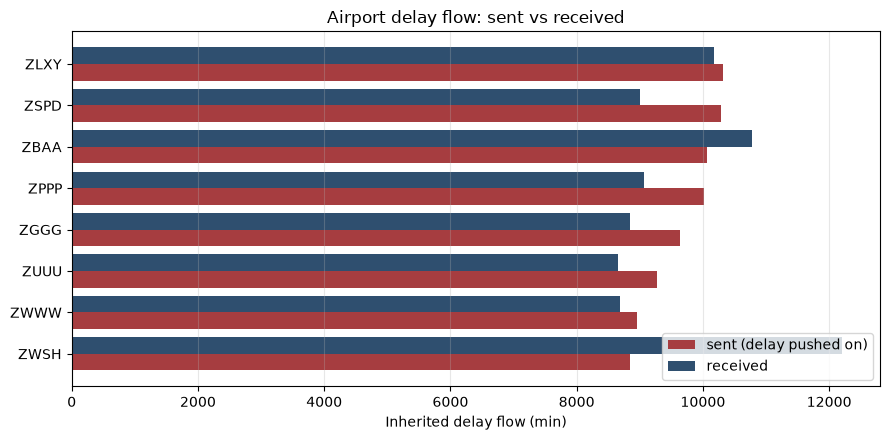

,sent,received,net
ZLXY,10317.8,10169.8,148.0
ZSPD,10289.5,8997.0,1292.5
ZBAA,10062.6,10776.8,-714.2
ZPPP,10023.7,9059.9,963.7
ZGGG,9635.0,8843.0,792.0
ZUUU,9266.0,8649.4,616.6
ZWWW,8948.0,8689.8,258.2
ZWSH,8839.1,12195.9,-3356.8


In [5]:
cent = airport_centrality(flights, chain, threshold_min=15)
top_sent = cent.head(8)

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(top_sent))
ax.barh(y + 0.2, top_sent["sent"], height=0.4, color="#a63d40", label="sent (delay pushed on)")
ax.barh(y - 0.2, top_sent["received"], height=0.4, color="#2f4f6f", label="received")
ax.set_yticks(y)
ax.set_yticklabels(top_sent.index)
ax.invert_yaxis()
ax.set_xlabel("Inherited delay flow (min)")
ax.set_title("Airport delay flow: sent vs received")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
cent.head(8)

## 5. 真实数据对照（OpenSky，可选）

合成数据证明了方法学有效；这一步用 **OpenSky 公开 REST 数据**对同一条流程做真实验证：
拉取上海浦东（ZSPD）近几天的到达记录，用「航线中位 block time」当伪时刻表估计延误
（该接口不提供计划时刻——这是公开数据的现实约束），机尾用应答器地址 icao24 充当。
带磁盘缓存与自动重试：**拉取失败时自动回退合成数据**，不影响案例主线。

In [6]:
import time

from routelab.opensky import arrivals_to_flights, fetch_arrivals

END = int(time.time()) - 6 * 3600          # 数据接口有 ~5.5h 延迟
BEGIN = END - 3 * 24 * 3600                # 最近 3 天

try:
    raw = fetch_arrivals("ZSPD", BEGIN, END, cache_dir="data_cache/opensky")
    real = arrivals_to_flights(raw, min_route_samples=5)
    if len(real) < 100:
        raise RuntimeError(f"only {len(real)} usable rows")
    real_chain = build_tail_chain(real, max_turnaround_min=180)
    real_stats = {t: delay_inheritance(real, real_chain, threshold_min=t)
                  for t in (15, 30, 60)}
    print(f"OpenSky 到达记录: {len(raw)} -> 可用 {len(real)} | "
          f"机尾(icao24) {real['registration'].nunique()}")
    DATA_SOURCE = "opensky"
except Exception as exc:
    print(f"[OpenSky 拉取失败，回退合成数据对照] 原因: {exc}")
    DATA_SOURCE = "synthetic"
    real = flights.sample(n=min(6000, len(flights)), random_state=1)
    real_chain = build_tail_chain(real, max_turnaround_min=180)
    real_stats = {t: delay_inheritance(real, real_chain, threshold_min=t)
                  for t in (15, 30, 60)}

[OpenSky 拉取失败，回退合成数据对照] 原因: OpenSky arrivals for ZSPD failed after 6 attempts: [WinError 10061] 由于目标计算机积极拒绝，无法连接。


In [7]:
compare = pd.DataFrame(rows).set_index("阈值 min").rename(
    columns={"P(下一班延误|上一班延误)": "合成数据", "lift": "合成 lift"}
)
compare["本节数据"] = [
    round(s["p_next_given_prev"], 3) if (s := real_stats[t])["p_next_given_prev"] else float("nan")
    for t in compare.index
]
compare["本节 lift"] = [
    round(s["lift"], 2) if (s := real_stats[t])["lift"] else None for t in compare.index
]
compare[["合成数据", "本节数据", "合成 lift", "本节 lift"]]

,合成数据,本节数据,合成 lift,本节 lift
阈值 min,,,,
15,0.704,0.703,2.57,2.56
30,0.739,0.754,3.97,4.13
60,0.756,0.789,7.43,7.64


**读数指引**：
- 若本节用的是 OpenSky 真实数据——把真实 lift 与合成 lift 放在一起：真实世界的传播通常弱于
  合成注入（航司有缓冲、有调机），但只要 lift 明显大于 1，"延误沿机尾链传播"这一判断就成立；
- 若本节回退成了合成数据——结构与方法完全相同，等拿到稳定的网络环境再重跑本节即可
  （拉取结果已按时间窗缓存，成功一次后离线可复现）。

## 结论与局限

- **方法学验收通过**：合成数据里注入的传播被 lift 清晰捞出（15 min 阈值下 lift ≈ 2.5–2.6）；
- 传播枢纽的排名揭示了"延误在哪些机场的过站中最容易落地"，继承延误分钟则回答"有多严重"；
- sent/received 流量把延误问题从"单个航班"提升到"网络结构"——net > 0 的机场是运行控制
  该重点盯防的放大器。

**局限**：合成数据只验证方法学；链模型只含机尾轮转，不含机组排班/维修/时刻协调；
OpenSky 对照的"延误"基于航线中位 block time 伪时刻表，是近似值；icao24 充当机尾身份
（等价于注册号用于建链，但不是民航注册号）。改进方向：接入 `traffic` 库读取 OpenSky
历史轨迹以获得真实注册号与时刻表对照。